# Code to generate Figures for the HLA Autoreactome paper

## Rayo Suseno

Please use the `peptidome` conda environment stored under `peptidome.yml` file to run this notebook

In [2]:
import pandas as pd
import numpy as np
import scipy
import sklearn
import re
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt
import statistics
from umap.umap_ import UMAP
import phippery
import xarray as xr
import seaborn as sns
import xgboost as xgb
from xgboost import plot_importance
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
import xgboost as xgb
from xgboost import XGBClassifier
from xgboost import cv
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from numpy import mean, std
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.stats import kruskal
from scipy.stats import ranksums
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
import pronto
from imblearn.under_sampling import RandomUnderSampler
from statsmodels.stats.multitest import multipletests
from collections import Counter
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
# from scipy import interp  # For TPR interpolation
from numpy import interp
from tqdm import tqdm  # For progress bar
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import matplotlib.patches as patches
from sklearn.metrics import silhouette_score
import random
import matplotlib.gridspec as gridspec

n_jobs = -1

/home/arenschen/anaconda3/envs/peptidome/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Preparation

Load dataframe

In [3]:
bin_df = pd.read_csv('data/pairseq_results_bin.csv')
bin_all = bin_df.filter(like='HLA')
bin_all['peptide_id'] = bin_df['peptide_id']
bin_all = bin_all.set_index('peptide_id')

sample_count = {}
sample_count['01'] = 0
sample_count['03'] = 0
sample_count['04'] = 0
sample_count['07'] = 0
sample_count['15'] = 0
sample_count['rest'] = 0


def custom_sort(col):
    if col.startswith('HLADRB1_01'):
        sample_count['01'] += 1
        return ('1', col)
    elif col.startswith('HLADRB1_03'):
        sample_count['03'] += 1
        return ('2', col)
    elif col.startswith('HLADRB1_04'):
        sample_count['04'] += 1
        return ('3', col)
    elif col.startswith('HLADRB1_07'):
        sample_count['07'] += 1
        return ('4', col)
    elif col.startswith('HLADRB1_15'):
        sample_count['15'] += 1
        return ('5', col)
    else:
        sample_count['rest'] += 1
        return ('6', col)
sorted_columns = sorted(bin_all.columns, key=custom_sort)
bin_all = bin_all[sorted_columns]

/tmp/ipykernel_3348686/499586683.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bin_all['peptide_id'] = bin_df['peptide_id']


Perform Kruskal-Wallis to identify autoantibodies that are significantly different

In [4]:
hla_types = ["01", "03", "04", "07", "15"]
significant_autoantigens_dict = {}
print("Kruskal-Wallis Rank Sums Test on Binary Table")
n_jobs = -1  # use all available cores

for hla in hla_types:
    # Filter columns
    bin_all_hla = bin_all.filter(like=f'HLADRB1_{hla}').copy()
    bin_all_rest = bin_all.drop(bin_all_hla.columns, axis=1)

    # Convert to NumPy arrays
    bin_all_hla_np = bin_all_hla.to_numpy()
    bin_all_rest_np = bin_all_rest.to_numpy()

    # Parallel Kruskal-Wallis computation
    def compute_p(i):
        return kruskal(bin_all_hla_np[i, :], bin_all_rest_np[i, :])[1]

    p_values = Parallel(n_jobs=n_jobs)(delayed(compute_p)(i) for i in range(len(bin_all_hla_np)))
    p_values = np.array(p_values)

    # Bonferroni correction
    significant_autoantigens = np.where(p_values < (0.05 / 6))[0]
    
    # Store
    significant_autoantigens_dict[hla] = significant_autoantigens
    #print(f"Significant autoantigens for {hla}:", len(significant_autoantigens))

kw_bin_pep = significant_autoantigens_dict
kw_bin_pep_01 = bin_all.iloc[significant_autoantigens_dict['01']].index
kw_bin_pep_03 = bin_all.iloc[significant_autoantigens_dict['03']].index
kw_bin_pep_04 = bin_all.iloc[significant_autoantigens_dict['04']].index
kw_bin_pep_07 = bin_all.iloc[significant_autoantigens_dict['07']].index
kw_bin_pep_15 = bin_all.iloc[significant_autoantigens_dict['15']].index

# Now get entries exclusive to each list
all_lists = [kw_bin_pep_01, kw_bin_pep_03, kw_bin_pep_04, kw_bin_pep_07, kw_bin_pep_15]
flat = [item for sublist in all_lists for item in sublist]
counts = Counter(flat)
exclusives = []
for lst in all_lists:
    exclusive = [item for item in lst if counts[item] == 1]
    exclusives.append(exclusive)
kw_bin_pep_01_exclusive, kw_bin_pep_03_exclusive, kw_bin_pep_04_exclusive, kw_bin_pep_07_exclusive, kw_bin_pep_15_exclusive = exclusives

print(len(kw_bin_pep_01), len(kw_bin_pep_01_exclusive))
print(len(kw_bin_pep_03), len(kw_bin_pep_03_exclusive))
print(len(kw_bin_pep_04), len(kw_bin_pep_04_exclusive))
print(len(kw_bin_pep_07), len(kw_bin_pep_07_exclusive))
print(len(kw_bin_pep_15), len(kw_bin_pep_15_exclusive))

Kruskal-Wallis Rank Sums Test on Binary Table
1029 1023
1297 1293
5691 5685
909 907
453 450


Get dataframe with just peptides that are exclusive to each HLA-DRB1 genotype

In [6]:
bin_15 = bin_all.filter(like='HLADRB1_15')
bin_07 = bin_all.filter(like='HLADRB1_07')
bin_04 = bin_all.filter(like='HLADRB1_04')
bin_03 = bin_all.filter(like='HLADRB1_03')
bin_01 = bin_all.filter(like='HLADRB1_01')

# peps = list(kw_bin_pep_15) + list(kw_bin_pep_07) + list(kw_bin_pep_03) + list(kw_bin_pep_01)
peps = list(kw_bin_pep_15_exclusive) + list(kw_bin_pep_07_exclusive) + list(kw_bin_pep_04_exclusive)+ list(kw_bin_pep_03_exclusive) + list(kw_bin_pep_01_exclusive)
bin_mlr = pd.concat([bin_15, bin_07, bin_04, bin_03, bin_01], axis=1)
enriched_df = bin_mlr[bin_mlr.index.isin(peps)]


Running logistic regression on HLA-DRB1*01


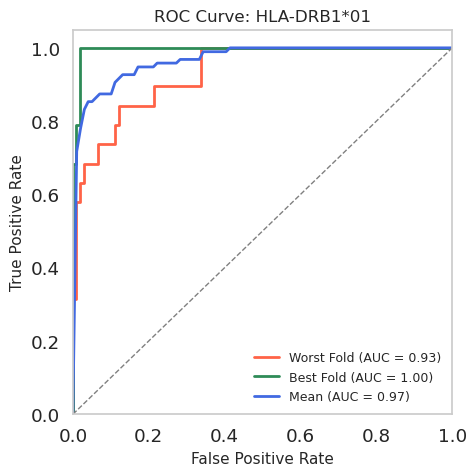


Fold closest to mean AUC (0.97):
Accuracy: 0.96
F1 Score (Rest): 0.98
F1 Score (HLA-01): 0.85
Macro F1 Score: 0.91


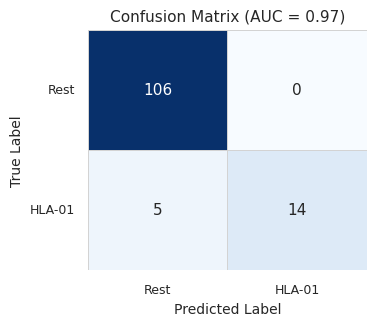

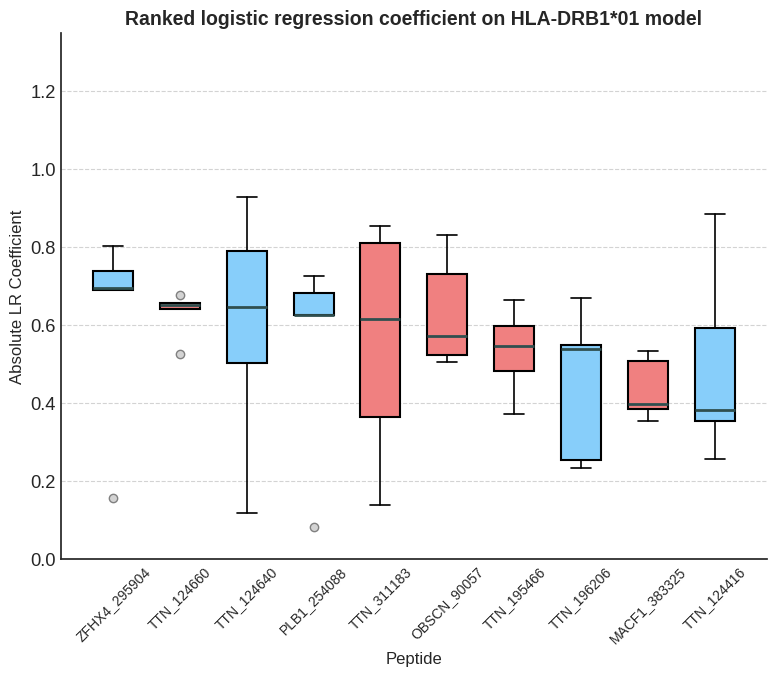

Saved ranked LR coefficients dataframe to variable 'lr_coeff_01' (top 5 rows):
        peptide  abs_coef
0   OBSCN_90057  0.632132
1    TTN_124660  0.630393
2  ZFHX4_295904  0.617035
3    TTN_124640  0.596690
4    TTN_311183  0.556738

Running logistic regression on HLA-DRB1*03


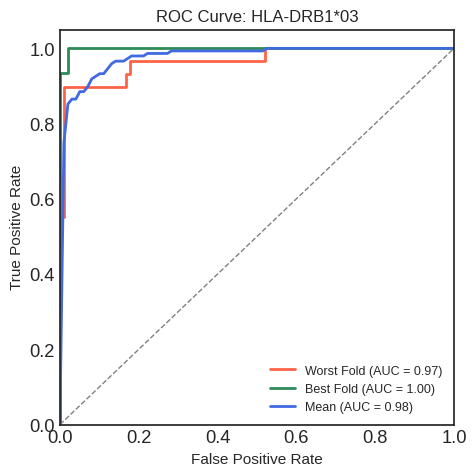


Fold closest to mean AUC (0.98):
Accuracy: 0.92
F1 Score (Rest): 0.95
F1 Score (HLA-03): 0.79
Macro F1 Score: 0.87


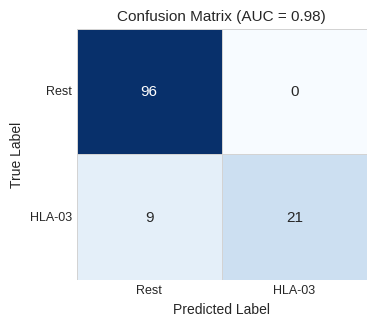

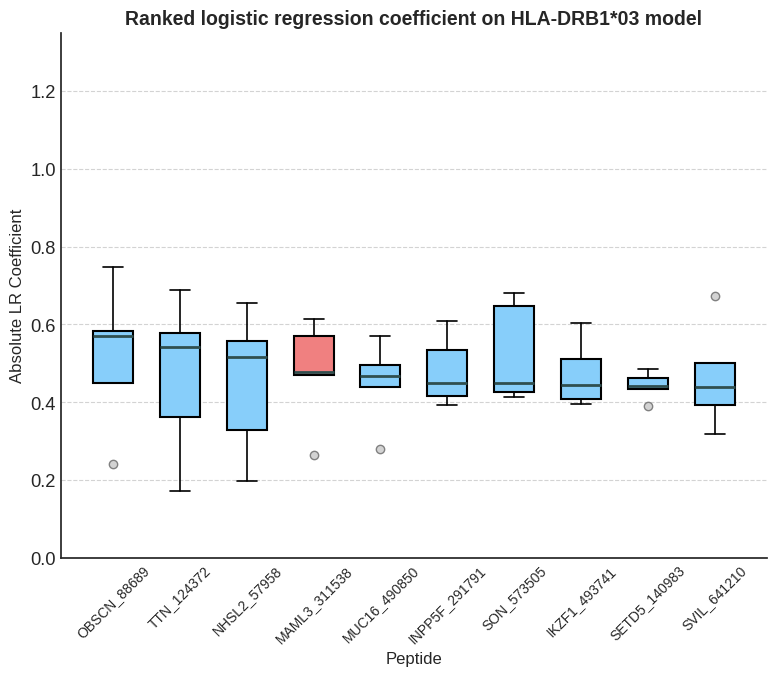

Saved ranked LR coefficients dataframe to variable 'lr_coeff_03' (top 5 rows):
         peptide  abs_coef
0     SON_573505  0.523144
1    OBSCN_88689  0.517692
2  INPP5F_291791  0.480344
3   MAML3_311538  0.478938
4   IKZF1_493741  0.473127

Running logistic regression on HLA-DRB1*04


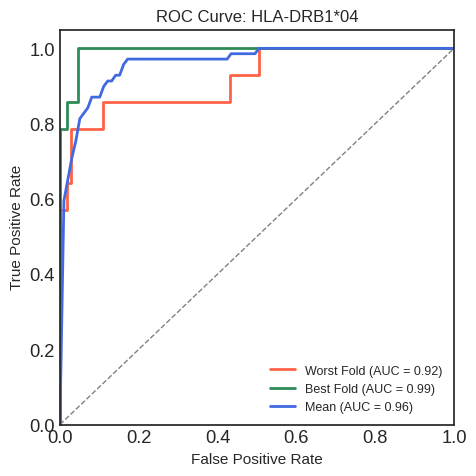


Fold closest to mean AUC (0.96):
Accuracy: 0.90
F1 Score (Rest): 0.94
F1 Score (HLA-04): 0.13
Macro F1 Score: 0.54


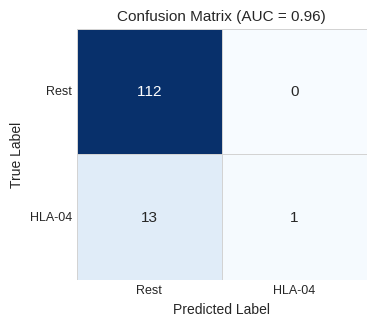

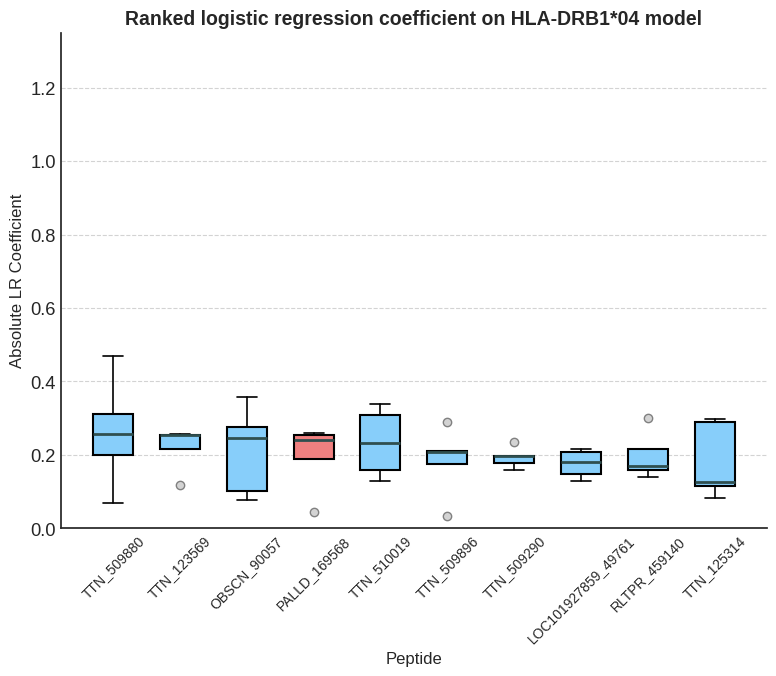

Saved ranked LR coefficients dataframe to variable 'lr_coeff_04' (top 5 rows):
        peptide  abs_coef
0    TTN_509880  0.260669
1    TTN_510019  0.233329
2    TTN_123569  0.219959
3   OBSCN_90057  0.211452
4  PALLD_169568  0.196935

Running logistic regression on HLA-DRB1*07


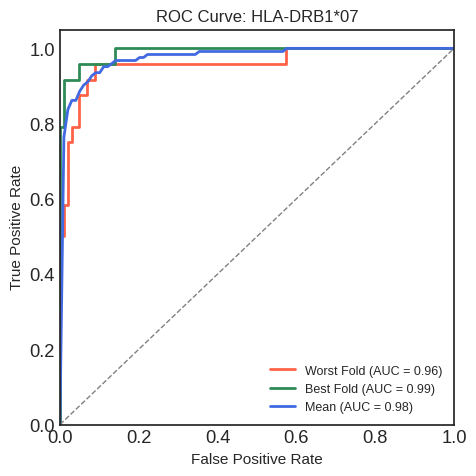


Fold closest to mean AUC (0.98):
Accuracy: 0.94
F1 Score (Rest): 0.97
F1 Score (HLA-07): 0.84
Macro F1 Score: 0.90


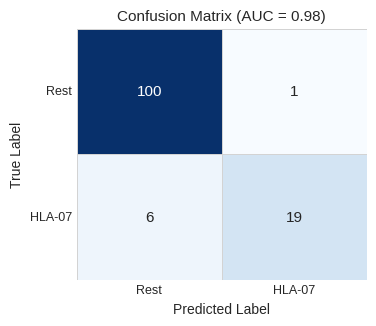

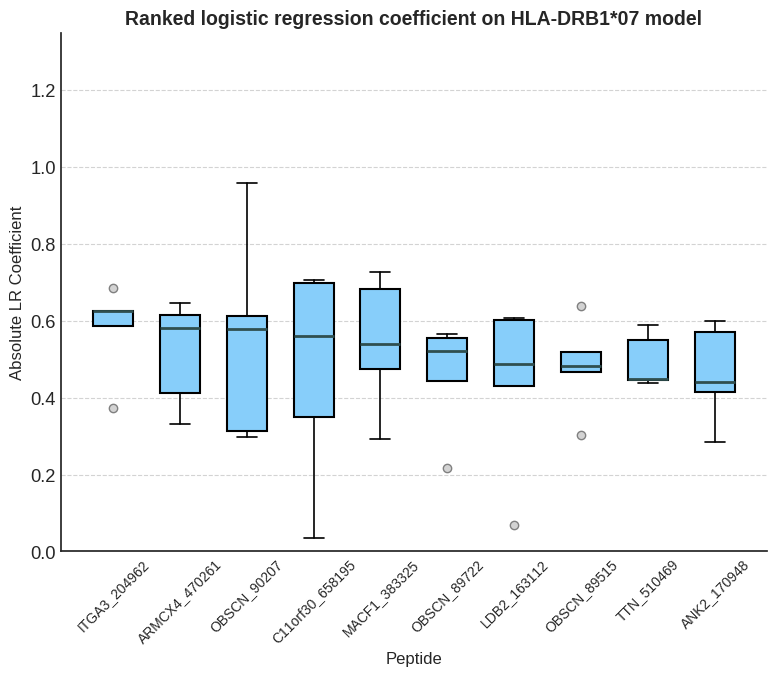

Saved ranked LR coefficients dataframe to variable 'lr_coeff_07' (top 5 rows):
         peptide  abs_coef
0   ITGA3_204962  0.579405
1    OBSCN_90207  0.551949
2   MACF1_383325  0.543731
3  ARMCX4_470261  0.517022
4     TTN_510469  0.494372

Running logistic regression on HLA-DRB1*15


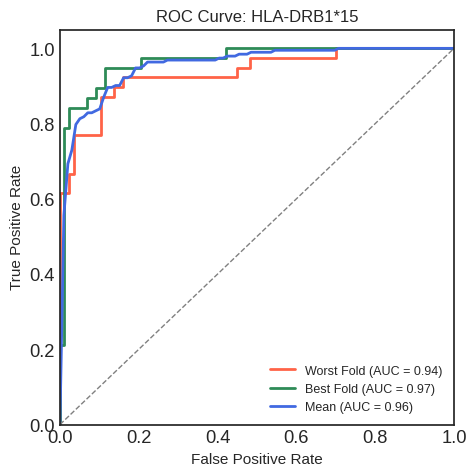


Fold closest to mean AUC (0.96):
Accuracy: 0.90
F1 Score (Rest): 0.93
F1 Score (HLA-15): 0.81
Macro F1 Score: 0.87


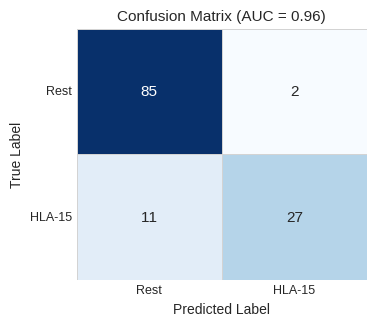

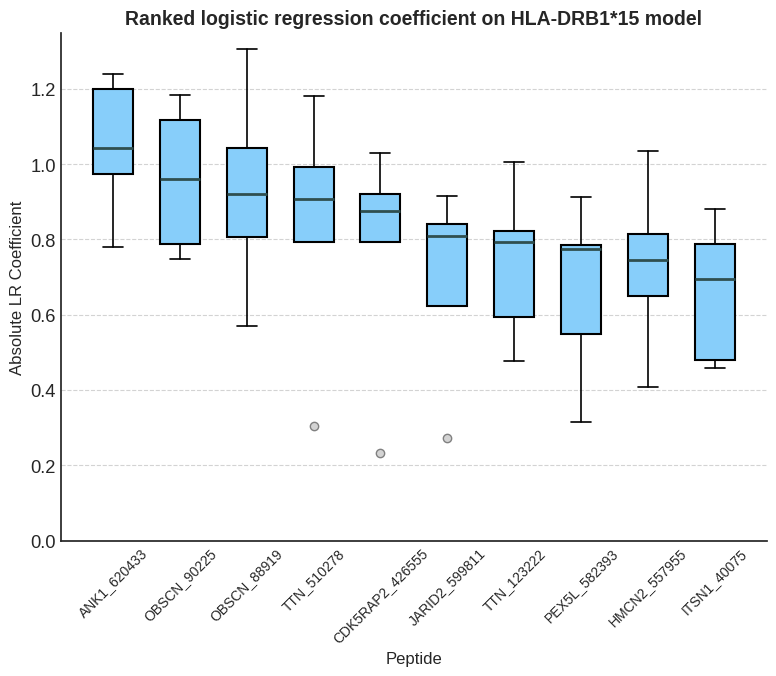

Saved ranked LR coefficients dataframe to variable 'lr_coeff_15' (top 5 rows):
           peptide  abs_coef
0      ANK1_620433  1.047751
1      OBSCN_90225  0.960173
2      OBSCN_88919  0.929525
3       TTN_510278  0.836072
4  CDK5RAP2_426555  0.770726


{'01':                peptide  abs_coef
 0          OBSCN_90057  0.632132
 1           TTN_124660  0.630393
 2         ZFHX4_295904  0.617035
 3           TTN_124640  0.596690
 4           TTN_311183  0.556738
 ...                ...       ...
 1024     TRIP12_129814  0.029668
 1025    RPGRIP1_532583  0.028847
 1026  KIAA1549L_651355  0.023503
 1027     KLHDC4_554470  0.008773
 1028      NRXN1_431753  0.002239
 
 [1029 rows x 2 columns],
 '03':             peptide  abs_coef
 0        SON_573505  0.523144
 1       OBSCN_88689  0.517692
 2     INPP5F_291791  0.480344
 3      MAML3_311538  0.478938
 4      IKZF1_493741  0.473127
 ...             ...       ...
 1292  SMURF2_446639  0.022947
 1293  CCDC57_504136  0.020284
 1294  AHNAK2_300199  0.016209
 1295  GPRIN3_170793  0.011236
 1296  INPP5F_291970  0.008239
 
 [1297 rows x 2 columns],
 '04':             peptide  abs_coef
 0        TTN_509880  0.260669
 1        TTN_510019  0.233329
 2        TTN_123569  0.219959
 3       OBSCN_90057  

In [11]:
def run_lr_full_cv(df, pep_dict, n_splits=5):
    sns.set(style="whitegrid", font_scale=1.2)
    hla_types = ["01", "03", "04", "07", "15"]
    lr_coeffs_all_hlas = {} # to store coefficients for all peptides
    ranked_coeff_figs_all_hlas = {}
    
    for hla in hla_types:
        print(f'\nRunning logistic regression on HLA-DRB1*{hla}')
        enriched_df = df[df.index.isin(eval(pep_dict + '_' + hla))]
        label = [1 if f'HLADRB1_{hla}' in i else 0 for i in enriched_df.columns]

        X = enriched_df.T
        y = label

        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

        fpr_interp = np.linspace(0, 1, 100)
        tprs_all = []
        aucs = []
        accs = []
        roc_curves = []
        cms = []

        for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
            X_train, X_test = X.iloc[train_index], X.iloc[test_index]
            y_train, y_test = np.array(y)[train_index], np.array(y)[test_index]

            undersampler = RandomUnderSampler(random_state=fold_idx)
            X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)

            logreg = LogisticRegression(max_iter=1000)
            logreg.fit(X_train_resampled, y_train_resampled)

            y_prob = logreg.predict_proba(X_test)[:, 1]
            y_pred = logreg.predict(X_test)

            fpr, tpr, _ = roc_curve(y_test, y_prob)
            auc = roc_auc_score(y_test, y_prob)
            acc = accuracy_score(y_test, y_pred)

            tpr_interp = np.interp(fpr_interp, fpr, tpr)
            tpr_interp[0] = 0.0
            tprs_all.append(tpr_interp)
            aucs.append(auc)
            accs.append(acc)
            roc_curves.append((fpr, tpr))
            cms.append(confusion_matrix(y_test, y_pred))

        # Best, worst, average
        best_idx = np.argmax(aucs)
        worst_idx = np.argmin(aucs)
        mean_tpr = np.mean(tprs_all, axis=0)
        mean_tpr[-1] = 1.0
        mean_auc = np.mean(aucs)
        mean_acc = np.mean(accs)

        # Plot ROC Curves
        plt.figure(figsize=(5, 5))
        plt.plot(roc_curves[worst_idx][0], roc_curves[worst_idx][1], color='tomato', lw=2,
                label='Worst Fold (AUC = {:.2f})'.format(aucs[worst_idx]))
        plt.plot(roc_curves[best_idx][0], roc_curves[best_idx][1], color='seagreen', lw=2,
                label='Best Fold (AUC = {:.2f})'.format(aucs[best_idx]))
        plt.plot(fpr_interp, mean_tpr, color='royalblue', lw=2,
                label='Mean (AUC = {:.2f})'.format(mean_auc))
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1)

        plt.xlabel('False Positive Rate', fontsize=11)
        plt.ylabel('True Positive Rate', fontsize=11)
        plt.title(f'ROC Curve: HLA-DRB1*{hla}', fontsize=12)
        plt.legend(loc="lower right", frameon=False, fontsize=9)
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        # plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.grid(False)
        plt.show()

        # Pick confusion matrix from fold with AUC closest to the mean
        mean_auc = np.mean(aucs)
        closest_idx = np.argmin(np.abs(np.array(aucs) - mean_auc))
        cm = cms[closest_idx]
        accuracy = np.trace(cm) / np.sum(cm)

        # Get F1 scores
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = np.array(y)[train_index], np.array(y)[test_index]
        undersampler = RandomUnderSampler(random_state=closest_idx)
        X_train_resampled, y_train_resampled = undersampler.fit_resample(X_train, y_train)
        logreg = LogisticRegression(max_iter=1000)
        logreg.fit(X_train_resampled, y_train_resampled)
        y_pred = logreg.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        f1_scores = f1_score(y_test, y_pred, average=None)  # [class 0, class 1]
        f1_macro = f1_score(y_test, y_pred, average='macro')  # for overall
        print(f"\nFold closest to mean AUC ({mean_auc:.2f}):")
        print(f"Accuracy: {acc:.2f}")
        print(f"F1 Score (Rest): {f1_scores[0]:.2f}")
        print(f"F1 Score (HLA-{hla}): {f1_scores[1]:.2f}")
        print(f"Macro F1 Score: {f1_macro:.2f}")

        # Plot Confusion Matrix
        plt.figure(figsize=(4, 3.5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                    annot_kws={"size": 11}, linewidths=0.5, linecolor='lightgray',
                    xticklabels=['Rest', f'HLA-{hla}'], yticklabels=['Rest', f'HLA-{hla}'])

        plt.title(f'Confusion Matrix (AUC = {aucs[closest_idx]:.2f})', fontsize=11)
        plt.xlabel('Predicted Label', fontsize=10)
        plt.ylabel('True Label', fontsize=10)
        plt.xticks(fontsize=9)
        plt.yticks(fontsize=9, rotation=0)
        plt.tight_layout()
        plt.show()

        # Identify top 10 features based on average model coefficients
        coef_matrix = []
        for fold_idx, (train_index, test_index) in enumerate(skf.split(X, y)):
            X_train, _ = X.iloc[train_index], X.iloc[test_index]
            y_train = np.array(y)[train_index]
            undersampler = RandomUnderSampler(random_state=fold_idx)
            X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

            logreg = LogisticRegression(max_iter=1000)
            logreg.fit(X_resampled, y_resampled)
            coef_matrix.append(logreg.coef_[0])

        coef_matrix = np.array(coef_matrix)
        avg_coefs = np.mean(coef_matrix, axis=0)
        feature_names = X.columns

        # Get top 10 features by absolute average coefficient
        top_idx = np.argsort(np.abs(avg_coefs))[-10:][::-1]
        # Extract per-fold coefficients for these features (absolute values for plotting)
        top_feature_coefs = [np.abs(coef_matrix[:, i]) for i in top_idx]
        top_gene = [feature_names[i] for i in top_idx]
        colors = ['#87CEFA' if avg_coefs[i] > 0 else '#F08080' for i in top_idx]
        # Sort by median absolute coefficient (descending)
        medians = [np.median(vals) for vals in top_feature_coefs]
        sorted_data = sorted(zip(medians, top_gene, top_feature_coefs, colors), reverse=True)
        medians, top_gene, top_feature_coefs, colors = zip(*sorted_data)
        # Plot boxplot
        positions = np.arange(len(top_gene)) * 2
        fig = plt.figure(figsize=(8, 7))
        plt.style.use('seaborn-v0_8-white')
        box = plt.boxplot(
            top_feature_coefs,
            positions=positions,
            widths=1.2,
            patch_artist=True,
            medianprops=dict(color='#2F4F4F', linewidth=2),
            whiskerprops=dict(color='black', linewidth=1.2),
            capprops=dict(color='black', linewidth=1.2),
            flierprops=dict(marker='o', markerfacecolor='lightgrey', markersize=6, linestyle='none', markeredgecolor='grey')
        )
        # Apply colors based on sign
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_edgecolor('black')
            patch.set_linewidth(1.5)
        plt.xticks(positions, top_gene, rotation=45, ha='center', fontsize=10)
        plt.xlabel("Peptide", fontsize=12)
        plt.ylabel("Absolute LR Coefficient", fontsize=12)
        plt.title(f"Ranked logistic regression coefficient on HLA-DRB1*{hla} model", fontsize=14, weight='bold')
        plt.grid(True, color='lightgrey', linestyle='--', linewidth=0.8, axis='y')
        for spine in ['top', 'right']:
            plt.gca().spines[spine].set_visible(False)
        plt.ylim(0,1.35)
        plt.tight_layout()
        globals()[f"ranked_coeff_{hla}"] = fig
        plt.show()

        # NEW: Rank ALL features by absolute average LR coefficient and save as dataframe
        # Creates a dataframe with columns: 'peptide' and 'abs_coef', sorted descending.
        df_all_coefs = pd.DataFrame({
            'peptide': list(feature_names),
            'abs_coef': np.abs(avg_coefs)
        })
        df_all_coefs = df_all_coefs.sort_values(by='abs_coef', ascending=False).reset_index(drop=True)

        # Save to a variable named lr_coeff_<hla>, e.g. lr_coeff_15 or lr_coeff_07
        var_name = f"lr_coeff_{hla}"
        globals()[var_name] = df_all_coefs  # creates a global variable with that name
        lr_coeffs_all_hlas[hla] = df_all_coefs  # also store in dict to return later

        print(f"Saved ranked LR coefficients dataframe to variable '{var_name}' (top 5 rows):")
        print(df_all_coefs.head())
        # -------------------------

    return lr_coeffs_all_hlas

run_lr_full_cv(bin_mlr,'kw_bin_pep')

# Figure 1

Figure 1 was generated using InteractiVenn, using the file inside `data/Figure1Ainput` and `data/Figure1Binput`

# Figure 2

/home/arenschen/anaconda3/envs/peptidome/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


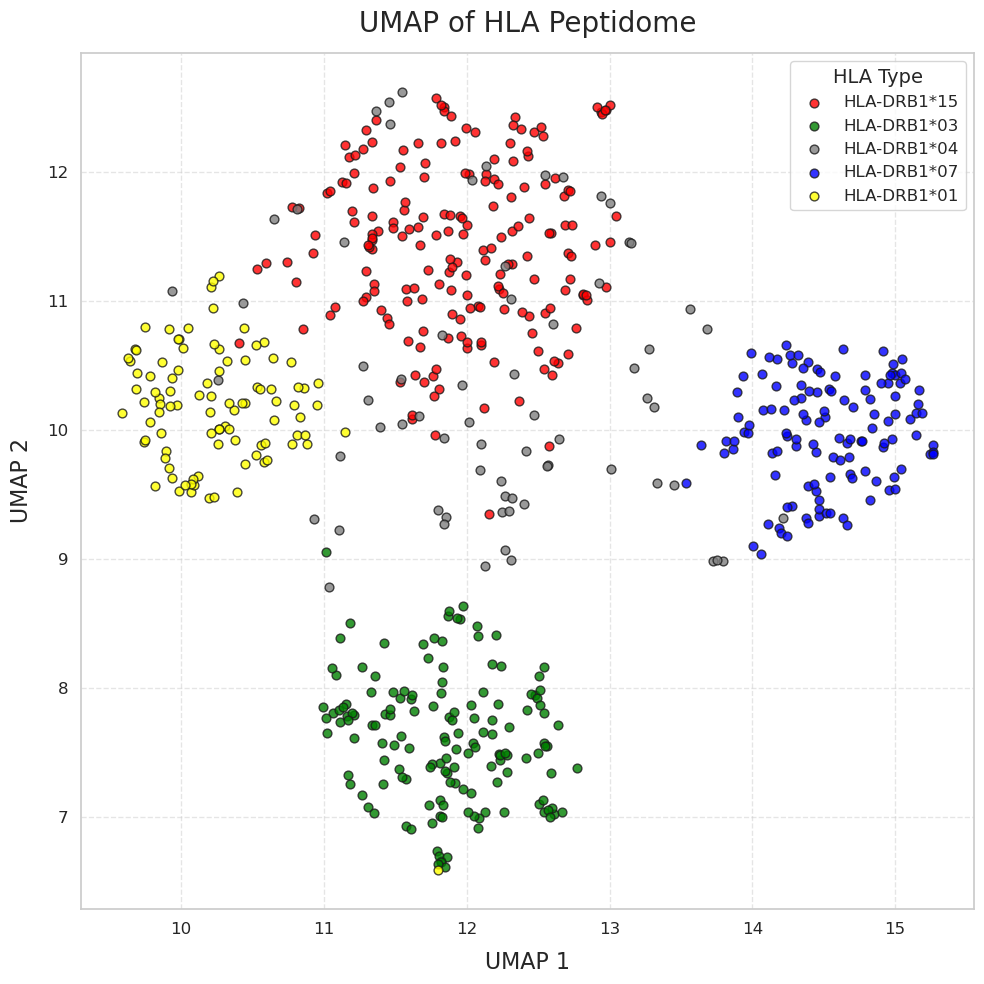

In [7]:
X = enriched_df.T.values
X_scaled = StandardScaler().fit_transform(X)
embedding = UMAP(
    n_neighbors=15,      # try 5, 15, 30
    min_dist=0.0,        # lower = tighter clusters
    n_components=2,
    metric='cosine',  # or try 'cosine'
    random_state=42
).fit_transform(X_scaled)
principalDf = pd.DataFrame(data = embedding, columns = ['PC1', 'PC2'])
target = enriched_df.columns.str.split(':').str[0]
target = pd.DataFrame(target, columns=['target'])
finalDf = pd.concat([principalDf, target], axis = 1)

# Set seaborn style
sns.set(style="whitegrid", context="notebook")

# Mapping old labels to new formatted labels and assigned colors
label_map = {
    'HLADRB1_15': 'HLA-DRB1*15',
    'HLADRB1_03': 'HLA-DRB1*03',
    'HLADRB1_04': 'HLA-DRB1*04',
    'HLADRB1_07': 'HLA-DRB1*07',
    'HLADRB1_01': 'HLA-DRB1*01'
}

color_map = {
    'HLADRB1_15': 'red',
    'HLADRB1_03': 'green',
    'HLADRB1_04': 'grey',
    'HLADRB1_07': 'blue',
    'HLADRB1_01': 'yellow'
}

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlabel('UMAP 1', fontsize=16, labelpad=10)
ax.set_ylabel('UMAP 2', fontsize=16, labelpad=10)
ax.set_title('UMAP of HLA Peptidome', fontsize=20, pad=15)

# Plot each group
for key in label_map:
    indicesToKeep = finalDf['target'] == key
    ax.scatter(finalDf.loc[indicesToKeep, 'PC1'],
               finalDf.loc[indicesToKeep, 'PC2'],
               c=color_map[key],
               s=40,
               edgecolor='k',
               alpha=0.8,
               label=label_map[key])

# Improve legend
ax.legend(title="HLA Type", fontsize=12, title_fontsize=14, loc='best')
ax.tick_params(axis='both', which='major', labelsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Figure 3

Figure 3 was generated using Microsoft's plotting capability with the metrics recorded from the function `run_lr_full_cv()` under the Preparation markdown above. These metrics are stored under `data/Figure3input.xlsx`

# Figure 4

Code defining the `ranked_coeff_{hla_genotype}` variable can be found under the `run_lr_full_cv()` function

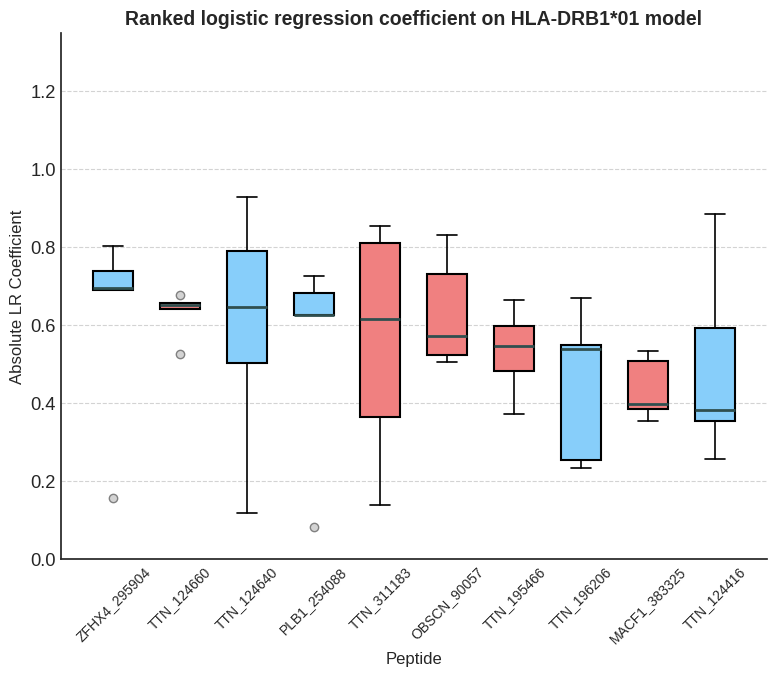

In [12]:
display(ranked_coeff_01)

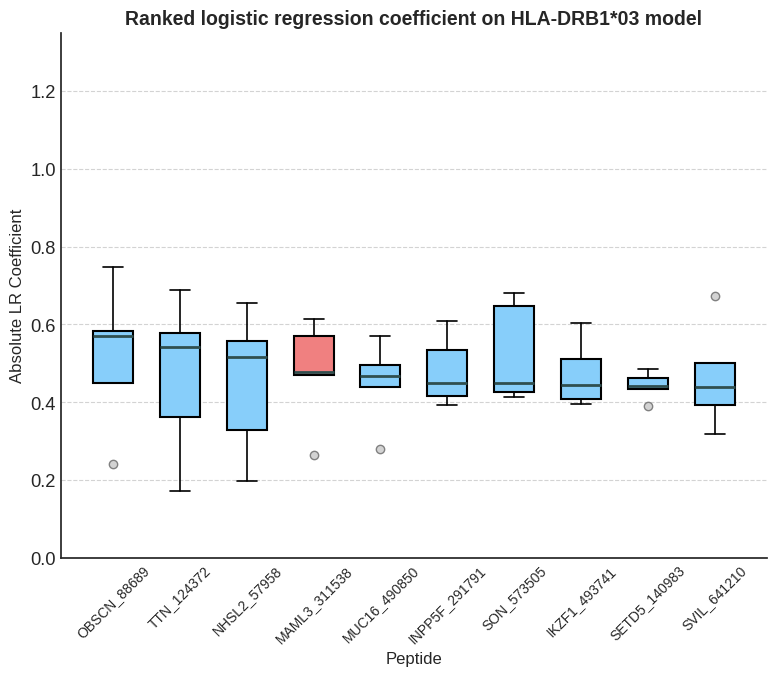

In [13]:
display(ranked_coeff_03)

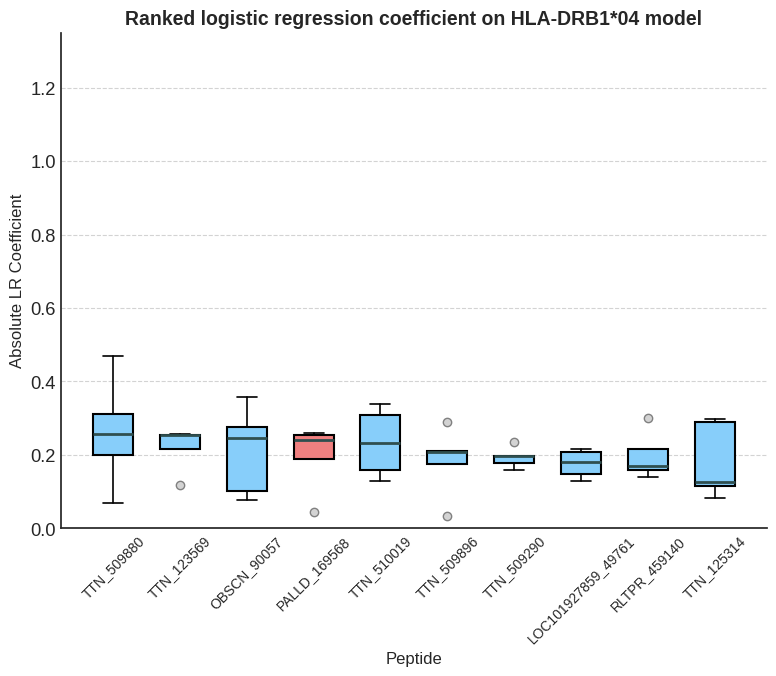

In [14]:
display(ranked_coeff_04)

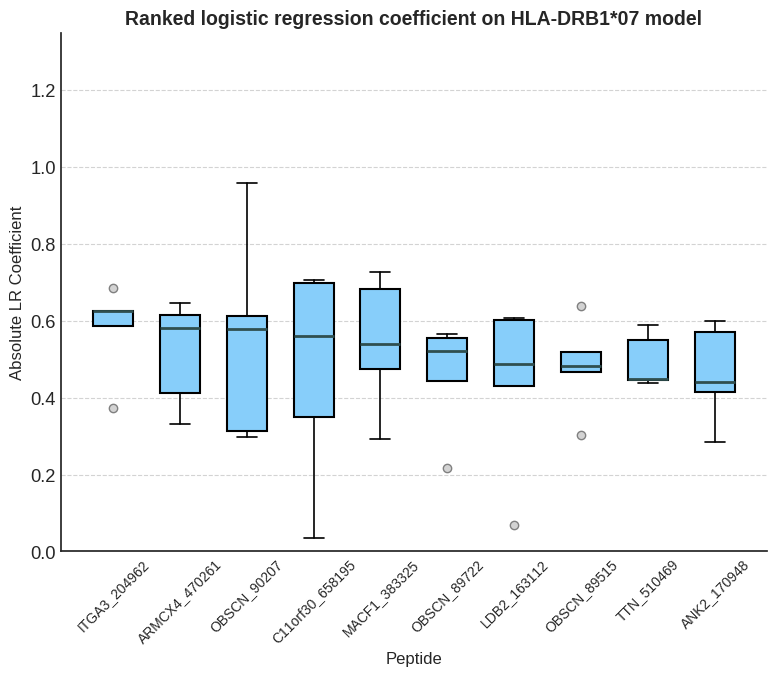

In [15]:
display(ranked_coeff_07)

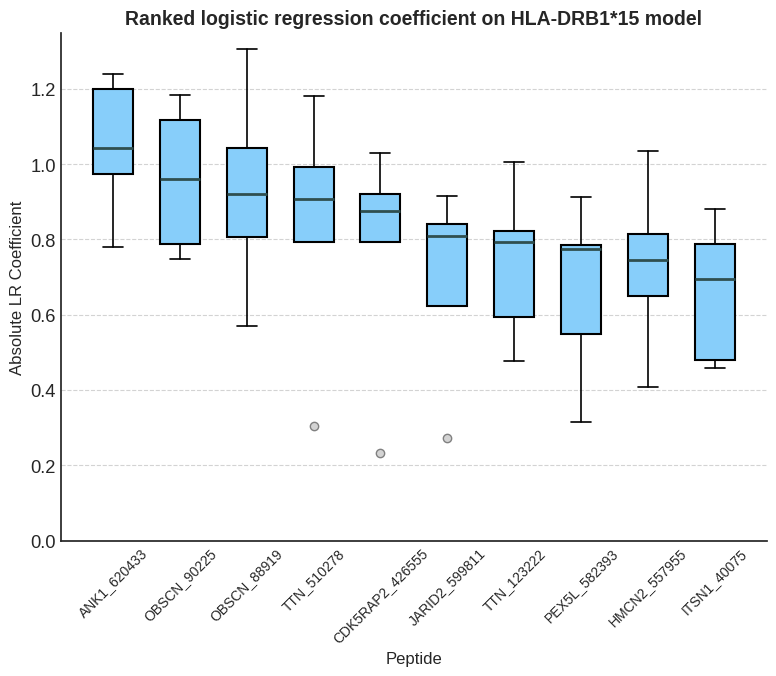

In [16]:
display(ranked_coeff_15)

# Figure 5

Figure 5A

/home/arenschen/anaconda3/envs/peptidome/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy of logistic regression classifier on test set:  0.76


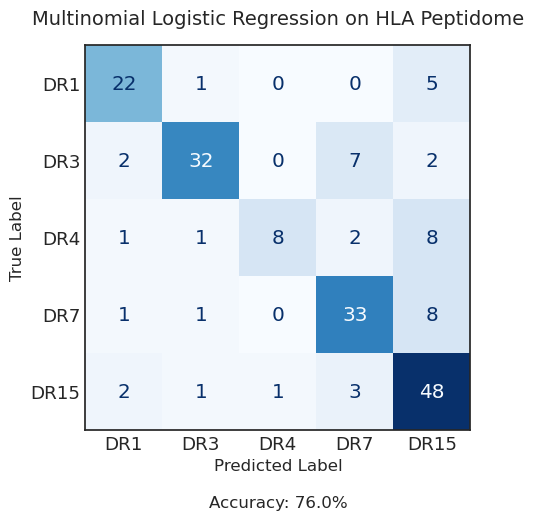

In [10]:
# Generate labels
labels = [col.split(':')[0] for col in enriched_df.columns]
custom_mapping = {
    'HLADRB1_15': 4,
    'HLADRB1_07': 3,
    'HLADRB1_04': 2,
    'HLADRB1_03': 1,
    'HLADRB1_01': 0}
label = np.array([custom_mapping[l] for l in labels])

X_train, X_test, y_train, y_test = train_test_split(enriched_df.T, label, test_size=0.3, random_state=10)

# Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

# Train model without class_weight
logreg = LogisticRegression(multi_class='multinomial', max_iter=1000)
logreg.fit(X_train_res, y_train_res)

# Evaluation
y_pred = logreg.predict(X_test)
acc = '{:.2f}'.format(logreg.score(X_test, y_test))
print('Accuracy of logistic regression classifier on test set: ', acc)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['DR1', 'DR3', 'DR4', 'DR7', 'DR15']
fig, ax = plt.subplots(figsize=(6, 5))
sns.set(font_scale=1.2)  # Increase font size
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
disp.ax_.grid(False)

ax.set_title('Multinomial Logistic Regression on HLA Peptidome', fontsize=14, pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
acc_text = f'Accuracy: {float(acc) * 100:.1f}%'
plt.annotate(acc_text, xy=(0.5, -0.20), xycoords='axes fraction',
             ha='center', fontsize=12)
# plt.tight_layout()
plt.show()


FIgure 5B

/home/arenschen/anaconda3/envs/peptidome/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy of logistic regression classifier on test set:  0.90


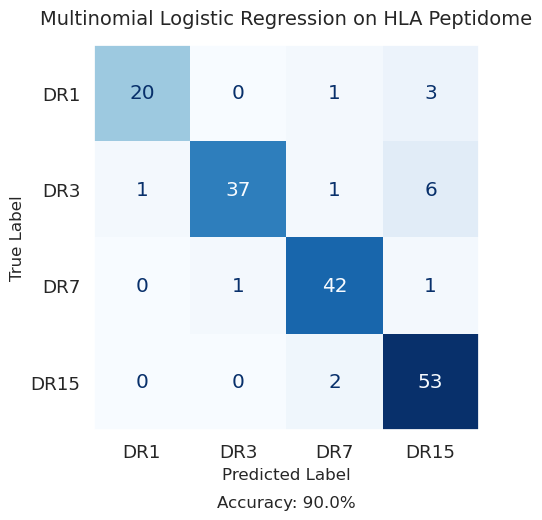

              precision    recall  f1-score   support

           0       0.95      0.83      0.89        24
           1       0.97      0.82      0.89        45
           2       0.91      0.95      0.93        44
           3       0.84      0.96      0.90        55

    accuracy                           0.90       168
   macro avg       0.92      0.89      0.90       168
weighted avg       0.91      0.90      0.90       168



In [18]:
peps = list(kw_bin_pep_15_exclusive) + list(kw_bin_pep_07_exclusive) + list(kw_bin_pep_03_exclusive) + list(kw_bin_pep_01_exclusive)
bin_mlr = pd.concat([bin_15, bin_07, bin_03, bin_01], axis=1)
enriched_df = bin_mlr[bin_mlr.index.isin(peps)]

# Generate labels
labels = [col.split(':')[0] for col in enriched_df.columns]
custom_mapping = {
    'HLADRB1_15': 3,
    'HLADRB1_07': 2,
    'HLADRB1_03': 1,
    'HLADRB1_01': 0}
label = np.array([custom_mapping[l] for l in labels])

X_train, X_test, y_train, y_test = train_test_split(enriched_df.T, label, test_size=0.3, random_state=10)

# Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_res, y_train_res = rus.fit_resample(X_train, y_train)

# Train model without class_weight
logreg = LogisticRegression(multi_class='multinomial', max_iter=1000)
logreg.fit(X_train_res, y_train_res)

# Evaluation
y_pred = logreg.predict(X_test)
acc = '{:.2f}'.format(logreg.score(X_test, y_test))
print('Accuracy of logistic regression classifier on test set: ', acc)

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
labels = ['DR1', 'DR3', 'DR7', 'DR15']
fig, ax = plt.subplots(figsize=(6, 5))
sns.set(font_scale=1.2)  # Increase font size
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
disp.ax_.grid(False)

ax.set_title('Multinomial Logistic Regression on HLA Peptidome', fontsize=14, pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
acc_text = f'Accuracy: {float(acc) * 100:.1f}%'
plt.annotate(acc_text, xy=(0.5, -0.20), xycoords='axes fraction',
             ha='center', fontsize=12)
# plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))